# Demographic features 

This notebook analyses the sociodemographic features at the LSOA scale. It uses data from the 2021 census via the London Datastore: https://data.london.gov.uk/census/ 

In [ ]:
import pandas as pd

import matplotlib.pyplot as plt

import geopandas as gpd

from database.comments import Comments
from database.topics import Topics

import sys
sys.path.append('../functions')
from nlp_tasks import NLP_Tasks
from elastic_search_fncs import ElasticSearchFncs

nlp_tasks = NLP_Tasks()
esf = ElasticSearchFncs()

cs = Comments(env="dev")
tp = Topics(env='dev')

/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use mps:0
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.
Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.
Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


### Load the 2021 census data 
The Census 2021 data comes from the London Datastore: https://data.london.gov.uk/census/2021-ward-and-lsoa-estimates/ 

In [2]:
df_age_census = pd.read_excel('../data/2021_census/Five year age bands.xlsx', sheet_name='2021')
df_occupation_census = pd.read_excel('../data/2021_census/occupation.xlsx', sheet_name='2021')
df_tenure_census = pd.read_excel('../data/2021_census/tenure - households.xlsx', sheet_name='2021')

In [3]:
df_age_census.head()

,LSOA code,local authority code,local authority name,All usual residents,Aged 4 and under,Aged 5 to 9,Aged 10 to 14,Aged 15 to 19,Aged 20 to 24,Aged 25 to 29,...,Aged 40 to 44,Aged 45 to 49,Aged 50 to 54,Aged 55 to 59,Aged 60 to 64,Aged 65 to 69,Aged 70 to 74,Aged 75 to 79,Aged 80 to 84,Aged 85 and over
0,E01000001,E09000001,City of London,1484,52,35,32,23,91,160,...,114,105,89,74,84,120,101,58,57,36
1,E01000002,E09000001,City of London,1382,34,23,22,30,100,166,...,92,95,122,89,87,74,70,59,43,32
2,E01000003,E09000001,City of London,1617,40,35,33,23,95,187,...,113,111,155,118,111,85,87,50,31,34
3,E01000005,E09000001,City of London,1098,50,44,35,89,118,96,...,62,59,87,84,65,35,26,17,13,13
4,E01032739,E09000001,City of London,1613,18,17,34,24,305,326,...,101,81,104,68,54,31,14,8,7,2


In [4]:
df_occupation_census.head()

,local authority code,local authority name,LSOA code,All usual residents aged 16 and over in employment,"1. Managers, directors and senior officials",2. Professional occupations,3. Associate professional and technical occupations,4. Adminis-trative and secretarial occupations,5. Skilled trades occupations,"6. Caring, leisure and other service occupations",7. Sales and customer service occupations,"8. Process, plant and machine operatives",9. Elementary occupations
0,E09000001,City of London,E01000001,868,194,406,184,39,5,19,11,6,4
1,E09000001,City of London,E01000002,875,218,414,187,35,3,5,3,3,7
2,E09000001,City of London,E01000003,1002,191,388,217,72,28,27,26,11,42
3,E09000001,City of London,E01000005,494,52,129,61,43,21,52,34,16,86
4,E09000001,City of London,E01032739,1184,253,540,216,48,23,37,40,6,21


In [5]:
df_tenure_census.head()

,LSOA code,local authority code,local authority name,All Households,Owned outright,Owned with a mortgage or loan,Shared ownership,Rented from Local Authority,Other social rented,Private landlord or letting agency,Other private rented,Rent free
0,E01000001,E09000001,City of London,843,338,144,3,17,4,283,53,1
1,E01000002,E09000001,City of London,825,283,149,2,23,6,324,38,0
2,E01000003,E09000001,City of London,1015,232,145,0,249,52,293,42,2
3,E01000005,E09000001,City of London,482,19,22,1,148,186,91,15,0
4,E01032739,E09000001,City of London,882,118,98,3,3,8,555,97,0


In [6]:
# add column >50 to df_age_census
df_age_census['age_50_plus'] = df_age_census[['Aged 50 to 54', 'Aged 55 to 59', 'Aged 60 to 64', 'Aged 65 to 69', 'Aged 70 to 74', 'Aged 75 to 79', 'Aged 80 to 84', 'Aged 85 and over']].sum(axis=1)
df_age_census['percent_age_50_plus'] = df_age_census['age_50_plus'] / df_age_census['All usual residents'] * 100

# add column summing 1,2,3 occupations to df_occupation_census
df_occupation_census['occupation_1_2_3'] = df_occupation_census[['1. Managers, directors and senior officials', '2. Professional occupations', '3. Associate professional and technical occupations']].sum(axis=1)
df_occupation_census['percent_occupation_1_2_3'] = df_occupation_census['occupation_1_2_3'] / df_occupation_census['All usual residents aged 16 and over in employment'] * 100

# add column owned outright + owned with mortgage to df_tenure_census
df_tenure_census['owned_total'] = df_tenure_census[['Owned outright', 'Owned with a mortgage or loan']].sum(axis=1)
df_tenure_census['percent_owned_total'] = df_tenure_census['owned_total'] / df_tenure_census['All Households'] * 100

In [7]:
# merge df_age_census with df_occupation_census and df_tenure_census on LSOA code
df_census = pd.merge(df_age_census[['LSOA code', 'percent_age_50_plus']], df_occupation_census[['LSOA code', 'percent_occupation_1_2_3']], on='LSOA code', how='left')
df_census = pd.merge(df_census, df_tenure_census[['LSOA code', 'percent_owned_total']], on='LSOA code', how='left')

In [8]:
df_census.head()

,LSOA code,percent_age_50_plus,percent_occupation_1_2_3,percent_owned_total
0,E01000001,41.711590,90.322581,57.176750
1,E01000002,41.678726,93.600000,52.363636
2,E01000003,41.496599,79.441118,37.142857
3,E01000005,30.965392,48.987854,8.506224
4,E01032739,17.854929,85.219595,24.489796


### Load the LSOA boundaries for London 
The LSOA boundaries come from ONS geoportal: https://geoportal.statistics.gov.uk/datasets/ons::lower-layer-super-output-areas-december-2021-boundaries-ew-bsc-v4-2/about

In [9]:
df_lsoa_boundaries = gpd.read_file('../data/london_geos/Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BSC_V4_-4299016806856585929.geojson')

In [10]:
df_lsoa_boundaries = df_lsoa_boundaries[df_lsoa_boundaries['LSOA21CD'].isin(df_age_census['LSOA code'])]

In [11]:
df_lsoa_boundaries

,FID,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,1,E01000001,City of London 001A,,532123,181632,51.51817,-0.097150,3478c558-3297-4e2b-979e-e29dd9ff3bf5,"POLYGON ((-0.09474 51.5206, -0.09546 51.51544,..."
1,2,E01000002,City of London 001B,,532480,181715,51.51883,-0.091970,f2072109-b1ae-426c-b166-083cc32f1789,"POLYGON ((-0.0881 51.51941, -0.09546 51.51544,..."
2,3,E01000003,City of London 001C,,532239,182033,51.52174,-0.095330,a9009c33-9b6b-4230-ba62-fc3264806de4,"POLYGON ((-0.09453 51.52205, -0.09274 51.52139..."
3,4,E01000005,City of London 001E,,533581,181283,51.51469,-0.076280,86aee0aa-079f-4f92-8f9d-5773824f4945,"POLYGON ((-0.07589 51.5159, -0.07394 51.51445,..."
4,5,E01000006,Barking and Dagenham 016A,,544994,184274,51.53875,0.089317,c33f1f5b-6b15-47a1-b046-b6a148a9f6d3,"POLYGON ((0.09328 51.53787, 0.09363 51.53767, ..."
...,...,...,...,...,...,...,...,...,...,...
33711,33712,E01035718,Westminster 019G,,527211,180107,51.50559,-0.168450,25d2ed9d-bacf-4bb8-b163-7c8707582116,"POLYGON ((-0.15093 51.50539, -0.15264 51.50382..."
33712,33713,E01035719,Westminster 021F,,530127,178755,51.49277,-0.126960,b6c58298-d3c0-4310-860d-03a7d428b2e2,"POLYGON ((-0.12467 51.49468, -0.12486 51.49437..."
33713,33714,E01035720,Westminster 021G,,530009,178440,51.48997,-0.128770,afdf4653-8bbb-47c3-ab02-a7bdba4f6a91,"POLYGON ((-0.13043 51.49225, -0.12659 51.49142..."
33714,33715,E01035721,Westminster 023H,,528403,178364,51.48965,-0.151920,a87a31c6-cc53-47ae-9476-49ade4103e55,"POLYGON ((-0.14841 51.49012, -0.1501 51.48789,..."


### Load the comments dataframe 
Read the remote database of free-text comments 

In [12]:
cs_df = cs.read_all()

In [13]:
cs_df

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score
0,88439,Barnet,23/4221/FUL_13,23/4221/FUL,45 Pine Grove Totteridge London N20 8LA,Objects,2023-11-08,I object to the proposed planning application ...,2025-04-10,51.632395,-0.194255,I object to the proposed planning application ...,E09000003,-0.244143
1,94013,Ealing,215737FUL_2,215737FUL,53 Gordon Road Ealing London W5 2AL W5 2AL,Objects,2021-10-30,I am writing as Chair of the GRASS (Gordon Roa...,2025-04-11,51.514611,-0.311787,I am writing as Chair of the GRASS ( and Surro...,E09000009,-0.232367
2,106710,Ealing,230760FUL_6,230760FUL,19 Studley Grange Road Hanwell W7 2Lu W7 2Lu,Objects,2023-09-24,"Dear Sir/Madam,\n\nAs a direct neighbour (on t...",2025-05-01,51.503314,-0.336865,"Dear Sir/Madam,\n\nAs a direct neighbour (on t...",E09000009,-0.167873
3,88908,Brent,20/0115_42,20/0115,"34 Gratton Terrace, London, NW2 6QE",Objects,2020-06-11,11/06/2020 - Further objection comment receive...,2025-04-10,51.560030,-0.218620,11/06/2020 - Further objection comment receive...,E09000003,-0.315872
4,76007,Barnet,22/4044/FUL_2,22/4044/FUL,8 May's Lane Barnet EN5 2EE,Objects,2022-09-05,CONTINUED\nArticle 8 of the Human Rights Act s...,2025-04-08,51.645724,-0.203315,CONTINUED\nArticle 8 of the Human Rights Act s...,E09000003,-0.229557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30388,73094,Barnet,23/4779/FUL_3,23/4779/FUL,106 torrington park london n129pj,Objects,2023-12-08,Council must Protecting Barnet's character and...,2025-04-04,51.507446,-0.127765,Council must Protecting Barnet's character and...,E09000033,-0.352118
30389,79288,Barnet,21/5247/FUL_21,21/5247/FUL,22 Lambert Road Finchley N12 9ES,Objects,2021-11-01,The plans submitted for this development are c...,2025-04-08,51.613109,-0.173991,The plans submitted for this development are c...,E09000003,-0.318891
30390,73102,Barnet,23/5391/FUL_4,23/5391/FUL,8 Shamrock Way London N14 5RY,Objects,2024-02-19,Dear Sir/Madam\nReference Planning Requests: 2...,2025-04-04,51.633100,-0.140270,Dear Sir/Madam\nReference Planning Requests: 2...,E09000003,-0.211599
30391,87675,Ealing,221304FUL_1,221304FUL,62 Mill Hill Road London W3 8JH W3 8JH,Objects,2022-07-30,I have read comments in 'support' of this exte...,2025-04-10,51.506210,-0.275670,I have read comments in 'support' of this exte...,E09000009,-0.225221


In [14]:
# get lsoa codes for comments using 'lat' and 'lon' to locate within df_lsoa_boundaries

cs_df['lsoa_code_updated'] = None

for lat, lon in zip(cs_df['lat'], cs_df['lon']):
    point = gpd.points_from_xy([lon], [lat])
    point_gdf = gpd.GeoDataFrame(geometry=point, crs='EPSG:4326')
    point_gdf = point_gdf.to_crs(df_lsoa_boundaries.crs)
    joined = gpd.sjoin(point_gdf, df_lsoa_boundaries, how='left')
    lsoa_code = joined.iloc[0]['LSOA21CD']
    cs_df.loc[(cs_df['lat'] == lat) & (cs_df['lon'] == lon), 'lsoa_code_updated'] = lsoa_code

In [15]:
cs_df

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score,lsoa_code_updated
0,88439,Barnet,23/4221/FUL_13,23/4221/FUL,45 Pine Grove Totteridge London N20 8LA,Objects,2023-11-08,I object to the proposed planning application ...,2025-04-10,51.632395,-0.194255,I object to the proposed planning application ...,E09000003,-0.244143,E01000279
1,94013,Ealing,215737FUL_2,215737FUL,53 Gordon Road Ealing London W5 2AL W5 2AL,Objects,2021-10-30,I am writing as Chair of the GRASS (Gordon Roa...,2025-04-11,51.514611,-0.311787,I am writing as Chair of the GRASS ( and Surro...,E09000009,-0.232367,E01001228
2,106710,Ealing,230760FUL_6,230760FUL,19 Studley Grange Road Hanwell W7 2Lu W7 2Lu,Objects,2023-09-24,"Dear Sir/Madam,\n\nAs a direct neighbour (on t...",2025-05-01,51.503314,-0.336865,"Dear Sir/Madam,\n\nAs a direct neighbour (on t...",E09000009,-0.167873,E01001253
3,88908,Brent,20/0115_42,20/0115,"34 Gratton Terrace, London, NW2 6QE",Objects,2020-06-11,11/06/2020 - Further objection comment receive...,2025-04-10,51.560030,-0.218620,11/06/2020 - Further objection comment receive...,E09000003,-0.315872,E01000141
4,76007,Barnet,22/4044/FUL_2,22/4044/FUL,8 May's Lane Barnet EN5 2EE,Objects,2022-09-05,CONTINUED\nArticle 8 of the Human Rights Act s...,2025-04-08,51.645724,-0.203315,CONTINUED\nArticle 8 of the Human Rights Act s...,E09000003,-0.229557,E01000292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30388,73094,Barnet,23/4779/FUL_3,23/4779/FUL,106 torrington park london n129pj,Objects,2023-12-08,Council must Protecting Barnet's character and...,2025-04-04,51.507446,-0.127765,Council must Protecting Barnet's character and...,E09000033,-0.352118,E01004736
30389,79288,Barnet,21/5247/FUL_21,21/5247/FUL,22 Lambert Road Finchley N12 9ES,Objects,2021-11-01,The plans submitted for this development are c...,2025-04-08,51.613109,-0.173991,The plans submitted for this development are c...,E09000003,-0.318891,E01000323
30390,73102,Barnet,23/5391/FUL_4,23/5391/FUL,8 Shamrock Way London N14 5RY,Objects,2024-02-19,Dear Sir/Madam\nReference Planning Requests: 2...,2025-04-04,51.633100,-0.140270,Dear Sir/Madam\nReference Planning Requests: 2...,E09000003,-0.211599,E01000120
30391,87675,Ealing,221304FUL_1,221304FUL,62 Mill Hill Road London W3 8JH W3 8JH,Objects,2022-07-30,I have read comments in 'support' of this exte...,2025-04-10,51.506210,-0.275670,I have read comments in 'support' of this exte...,E09000009,-0.225221,E01001351


In [16]:
# merge cs_df with df_age_census on lsoa_code to get percent_age_50_plus for each comment

cs_df = pd.merge(cs_df, df_census, left_on='lsoa_code_updated', right_on='LSOA code', how='left')

In [17]:
cs_df

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score,lsoa_code_updated,LSOA code,percent_age_50_plus,percent_occupation_1_2_3,percent_owned_total
0,88439,Barnet,23/4221/FUL_13,23/4221/FUL,45 Pine Grove Totteridge London N20 8LA,Objects,2023-11-08,I object to the proposed planning application ...,2025-04-10,51.632395,-0.194255,I object to the proposed planning application ...,E09000003,-0.244143,E01000279,E01000279,50.036576,77.317881,85.854617
1,94013,Ealing,215737FUL_2,215737FUL,53 Gordon Road Ealing London W5 2AL W5 2AL,Objects,2021-10-30,I am writing as Chair of the GRASS (Gordon Roa...,2025-04-11,51.514611,-0.311787,I am writing as Chair of the GRASS ( and Surro...,E09000009,-0.232367,E01001228,E01001228,26.663032,65.367582,37.605804
2,106710,Ealing,230760FUL_6,230760FUL,19 Studley Grange Road Hanwell W7 2Lu W7 2Lu,Objects,2023-09-24,"Dear Sir/Madam,\n\nAs a direct neighbour (on t...",2025-05-01,51.503314,-0.336865,"Dear Sir/Madam,\n\nAs a direct neighbour (on t...",E09000009,-0.167873,E01001253,E01001253,26.829268,58.630137,57.272727
3,88908,Brent,20/0115_42,20/0115,"34 Gratton Terrace, London, NW2 6QE",Objects,2020-06-11,11/06/2020 - Further objection comment receive...,2025-04-10,51.560030,-0.218620,11/06/2020 - Further objection comment receive...,E09000003,-0.315872,E01000141,E01000141,27.218935,42.928287,27.742749
4,76007,Barnet,22/4044/FUL_2,22/4044/FUL,8 May's Lane Barnet EN5 2EE,Objects,2022-09-05,CONTINUED\nArticle 8 of the Human Rights Act s...,2025-04-08,51.645724,-0.203315,CONTINUED\nArticle 8 of the Human Rights Act s...,E09000003,-0.229557,E01000292,E01000292,43.329016,66.812865,69.724771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30388,73094,Barnet,23/4779/FUL_3,23/4779/FUL,106 torrington park london n129pj,Objects,2023-12-08,Council must Protecting Barnet's character and...,2025-04-04,51.507446,-0.127765,Council must Protecting Barnet's character and...,E09000033,-0.352118,E01004736,E01004736,26.039536,80.389908,32.989691
30389,79288,Barnet,21/5247/FUL_21,21/5247/FUL,22 Lambert Road Finchley N12 9ES,Objects,2021-11-01,The plans submitted for this development are c...,2025-04-08,51.613109,-0.173991,The plans submitted for this development are c...,E09000003,-0.318891,E01000323,E01000323,29.598309,50.286182,34.257426
30390,73102,Barnet,23/5391/FUL_4,23/5391/FUL,8 Shamrock Way London N14 5RY,Objects,2024-02-19,Dear Sir/Madam\nReference Planning Requests: 2...,2025-04-04,51.633100,-0.140270,Dear Sir/Madam\nReference Planning Requests: 2...,E09000003,-0.211599,E01000120,E01000120,42.084168,64.964539,85.542169
30391,87675,Ealing,221304FUL_1,221304FUL,62 Mill Hill Road London W3 8JH W3 8JH,Objects,2022-07-30,I have read comments in 'support' of this exte...,2025-04-10,51.506210,-0.275670,I have read comments in 'support' of this exte...,E09000009,-0.225221,E01001351,E01001351,30.761421,54.652302,34.740651


In [18]:
lsoa_with_comment = cs_df['lsoa_code_updated'].unique()
# mean socioeconomic features across lsoa with comments
df_census[df_census['LSOA code'].isin(lsoa_with_comment)][['percent_age_50_plus', 'percent_occupation_1_2_3', 'percent_owned_total']].mean()

percent_age_50_plus         29.598996
percent_occupation_1_2_3    53.731280
percent_owned_total         46.137828
dtype: float64

In [19]:
# mean socioeconomic features across London
df_census[['percent_age_50_plus', 'percent_occupation_1_2_3', 'percent_owned_total']].mean()

percent_age_50_plus         29.205337
percent_occupation_1_2_3    55.001156
percent_owned_total         46.711435
dtype: float64

In [20]:
# test if group means differ significantly from overall means using t-test
from scipy import stats
for feature in ['percent_age_50_plus', 'percent_occupation_1_2_3', 'percent_owned_total']:
    overall_mean = df_census[feature].mean()
    overall_std = df_census[feature].std()
    overall_n = df_census.shape[0]
    print(f'Overall mean for {feature}: {overall_mean}')
    lsoa_with_comment_mean = df_census[df_census['LSOA code'].isin(lsoa_with_comment)][feature].mean()
    lsoa_with_comment_std = df_census[df_census['LSOA code'].isin(lsoa_with_comment)][feature].std()
    lsoa_with_comment_n = df_census[df_census['LSOA code'].isin(lsoa_with_comment)].shape[0]
    print(f'Mean for LSOA with comments for {feature}: {lsoa_with_comment_mean}')
    t_stat, p_value = stats.ttest_ind_from_stats(mean1=lsoa_with_comment_mean, std1=lsoa_with_comment_std, nobs1=lsoa_with_comment_n,
                                                             mean2=overall_mean, std2=overall_std, nobs2=overall_n,
                                                             equal_var=False)
    print(f'Test for {feature}: t-statistic = {t_stat}, p-value = {p_value}')

Overall mean for percent_age_50_plus: 29.205337340969997
Mean for LSOA with comments for percent_age_50_plus: 29.598995649243168
Test for percent_age_50_plus: t-statistic = 1.5805728240238517, p-value = 0.11414116592837413
Overall mean for percent_occupation_1_2_3: 55.00115622572938
Mean for LSOA with comments for percent_occupation_1_2_3: 53.731279772416315
Test for percent_occupation_1_2_3: t-statistic = -2.3685940212564365, p-value = 0.017965491259636323
Overall mean for percent_owned_total: 46.711435404421344
Mean for LSOA with comments for percent_owned_total: 46.137828322186486
Test for percent_owned_total: t-statistic = -0.9139372692902659, p-value = 0.3608609857579398


In [21]:
# mean and count of percent_age_50_plus grouped by lsoa_code_updated
cs_df.groupby('lsoa_code_updated')[['percent_age_50_plus', 'percent_occupation_1_2_3']].agg(['mean', 'count']).reset_index()

lsoa_code_updated percent_age_50_plus       percent_occupation_1_2_3  \
                                      mean count                     mean   
0            E01000001           41.711590     1                90.322581   
1            E01000002           41.678726     3                93.600000   
2            E01000003           41.496599     1                79.441118   
3            E01000005           30.965392     1                48.987854   
4            E01000035           29.935275     1                32.029340   
...                ...                 ...   ...                      ...   
1177         E01035484           23.924573     1                61.260054   
1178         E01035649           14.432285     1                78.190255   
1179         E01035710           21.453556     1                45.952381   
1180         E01035716           30.381471     4                73.158340   
1181         E01035721           35.573630     1                67.005545   

            
     count  
0        1  
1        3  
2        1  
3        1  
4        1  
...    ...  
1177     1  
1178     1  
1179     1  
1180     4  
1181     1  

[1182 rows x 5 columns]

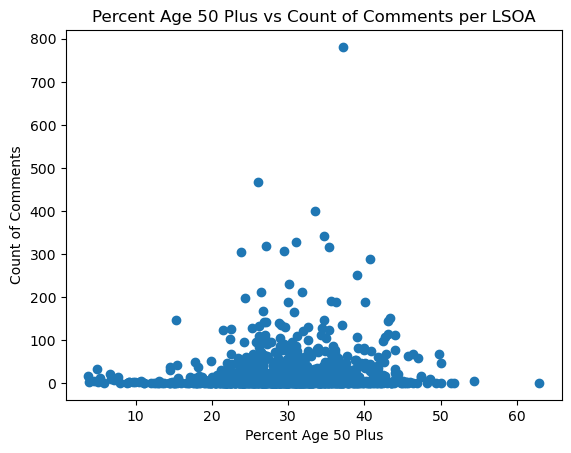

In [22]:
# scatter plot of percent_age_50_plus vs count of comments per lsoa_code_updated
grouped = cs_df.groupby('lsoa_code_updated').agg({'percent_age_50_plus': 'mean', 'comment_id': 'count'}).reset_index()
plt.scatter(grouped['percent_age_50_plus'], grouped['comment_id'])
plt.xlabel('Percent Age 50 Plus')
plt.ylabel('Count of Comments')
plt.title('Percent Age 50 Plus vs Count of Comments per LSOA')
plt.show()

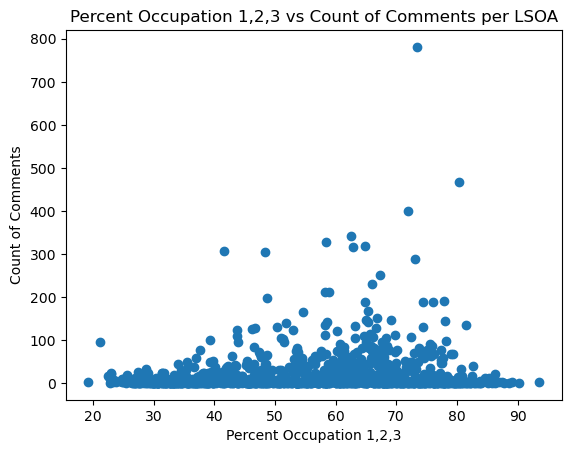

In [23]:
# scatter plot of percent_occupation_1_2_3 vs count of comments per lsoa_code_updated
grouped = cs_df.groupby('lsoa_code_updated').agg({'percent_occupation_1_2_3': 'mean', 'comment_id': 'count'}).reset_index()
plt.scatter(grouped['percent_occupation_1_2_3'], grouped['comment_id'])
plt.xlabel('Percent Occupation 1,2,3')
plt.ylabel('Count of Comments')
plt.title('Percent Occupation 1,2,3 vs Count of Comments per LSOA')
plt.show()

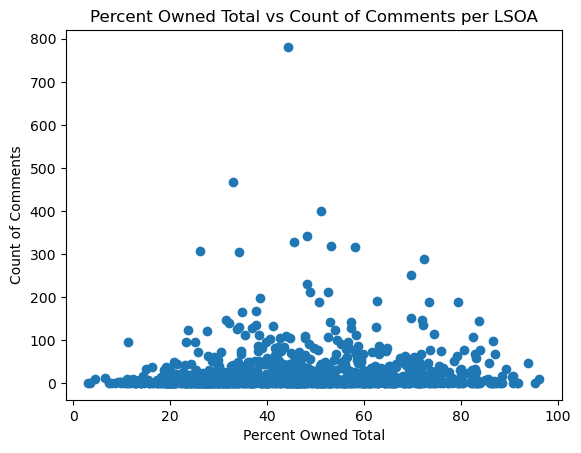

In [24]:
# scatter of percent_owned_total vs count of comments per lsoa_code_updated
grouped = cs_df.groupby('lsoa_code_updated').agg({'percent_owned_total': 'mean', 'comment_id': 'count'}).reset_index()
plt.scatter(grouped['percent_owned_total'], grouped['comment_id'])
plt.xlabel('Percent Owned Total')
plt.ylabel('Count of Comments')
plt.title('Percent Owned Total vs Count of Comments per LSOA')
plt.show()

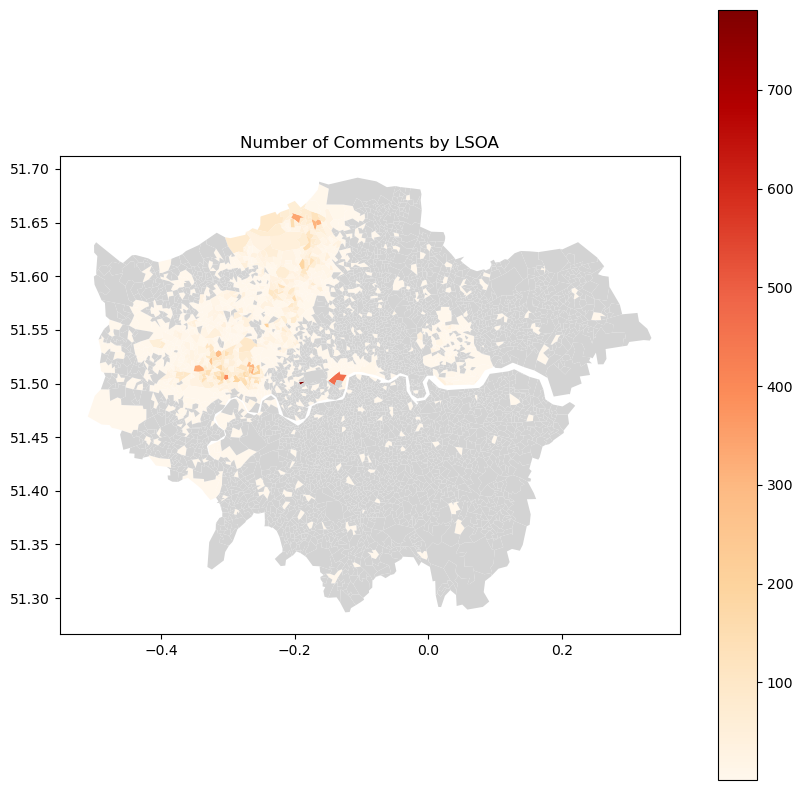

In [25]:
# plot map of number of comments per lsoa_code_updated
df_lsoa_boundaries = df_lsoa_boundaries.merge(cs_df.groupby('lsoa_code_updated')['percent_age_50_plus'].count().reset_index().rename(columns={'percent_age_50_plus': 'comment_count'}), left_on='LSOA21CD', right_on='lsoa_code_updated', how='left')   
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
df_lsoa_boundaries.plot(column='comment_count', ax=ax, legend=True, cmap='OrRd', missing_kwds={'color': 'lightgrey'})
ax.set_title('Number of Comments by LSOA')
plt.show()